# Testing logistic regression
In this File the algorithms are tested on the logistic regression problem: see also "An Adaptive and Parameter-Free Nesterov’s Accelerated Gradient Method for Convex Optimization"

$$min_{x \in \mathbb R^n} f(x)$$

Where $f(x) = -\frac{1}{m} \sum_{i=1}^{m} (y_i \text{log}(\sigma(a_i^T x)) + (1 - y_i) \text{log}(1 - \sigma(a_i^T x))) + \frac{\gamma}{2} \lVert x \rVert^2$, 

$A = [a_1 \dots a_m]^T \in \mathbb R^{m \times n}$, $y_i \in {0,1}$, $\sigma(z) = \frac{1}{1+ e^{-x}}$.

Note that the gradient of f is given by $\nabla f(x) = \frac{1}{m} \sum_{i=1}^{m} a_i(\sigma(a_i^T x) - y_i) + \gamma x$, which is Lipschitz continous with Lipschitz constant $L = \frac{1}{4 m} \lVert A^T A \rVert + \gamma = \frac{1}{4m} \text{max}_{i = 1, \dots n} \lambda_i + \gamma$ ($\lambda_i$ are the eigenvalues of $A^TA$)

The matrices $A$ and vectors $y$ that are used are mushrooms ($m=8124$, $n=112$) and w8a ($m=33453$, $n=300$) and covtype ($m=581012$, $n=54$) from LIBSVM.

As in Suh and Ma's paper I will choose $\gamma = \frac{L}{m}$ for mushrooms and w8a as well as $\gamma = \frac{L}{10m}$ for covtype. This can be achieved by substituting $\gamma$ in the equation for the Lipschitz constant and solving for $L$:

$$L = \frac{1}{4m} \text{max}_{i = 1, \dots n} \lambda_i + \frac{L}{m}$$
$$ \iff L = (1 - \frac{1}{m}) \frac{1}{4m} \text{max}_{i = 1, \dots n} \lambda_i$$

In [1]:
import numpy as np
import numpy.linalg as la
from Testing_functions import logistic_regression, logistic_gradient
import matplotlib.pyplot as plt
import time

In [2]:
from AdaAGM import AdaAGM
from Algorithms import constant_gradient, Nesterov_gradient, AdaNAG_G

## Setting up model problems

In [3]:
from sklearn.datasets import load_svmlight_file
import os

#loading mushrooms data
data_path = os.getcwd() + '\\datasets\\mushrooms'

data_matrix, data_vector = load_svmlight_file(data_path)
A_mushrooms = data_matrix.toarray()
#vector has entries 1,2, function needs vector with values 0, 1
y_mushrooms = data_vector - np.ones(np.size(data_vector))

#loading w8a data
data_path = os.getcwd() + '\\datasets\\w8a'

data_matrix, data_vector = load_svmlight_file(data_path)
A_w8a = data_matrix.toarray()
#vector has entries 1, -1, function only takes values 0, 1
data_vector[data_vector== -1] = 0
y_w8a = data_vector

#loading covtype data
data_path = os.getcwd() + '\\datasets\\covtype.bz2'

data_matrix, data_vector = load_svmlight_file(data_path)
A_covtype = data_matrix.toarray()
#vector has entries 1, 2, 3, 4, 5, 6, 7, function only takes values 0, 1
data_vector[data_vector%2== 0] = 0
data_vector[data_vector%2== 1] = 1
y_covtype = data_vector

Setting up the data sets

In [4]:
matrices = [("mushrooms", A_mushrooms), ("w8a", A_w8a), ("covtype", A_covtype)]
vectors = [y_mushrooms, y_w8a, y_covtype]
iteration_list = [500, 700, 9000]

## Setting up AdaAGM
Corollary 5.5 gives the following constants:
$\gamma = \frac{1}{2}, \beta = 1$, $m \in (0,1)$, $t_0 = 2$ and $\omega = \delta = \frac{1}{2}$.

Also the initial stepsize needs to satisfy the follwing: $s_0 \geq \frac{1}{12 L}$, which is guaranteed during the calculation of sequences.

I will choose $m = 0.1$, $m = 0.5$ and $m=0.9$

Note that Corollary 5.5 applies to functions $f$ that are strongly convex. The objective function of the regularized logistic regression is in fact strongly convex due to the regularization term.

In [5]:
t_5_0 = 2
omega_5 = 1/2
delta_5 = 1/2
beta_5 = 1
gamma_5 = 1/2
m_1 = 0.1
m_5 = 0.5
m_9 = 0.9

Corollary 5.6 gives the following constants: $\gamma = 1$, $\beta = \frac{1}{3}$, $m \in (0,1)$, $t_0 = 3$ and $\omega = \delta = \frac{1}{2}$

Also the initial stepsize needs to satisfy the follwing: $s_0 \geq \frac{1}{16 L}$, which is guaranteed during the calculation of sequences.

I will choose $m = 0.1$, $m = 0.5$ and $m=0.9$

In [6]:
t_6_0 = 3
omega_6 = 0.5
delta_6 = 0.5
beta_6 = 1/3
gamma_6 = 1

## Setting up AdaNAG_G$_{12}$ and AdaNAG_G$^{1 / 2}$
### Choices of constants and sequences
AdaNAG_G$_{12}$: Corollary 7 gives the follwing: $\tau_k = \frac{(k+2) + 12}{12}$, $\alpha_k = \frac{1}{2} \frac{(\tau_{k+1} - 1)^2}{\tau_k^2}$ and $B_0 = \alpha_0^2\tau_0^2(\frac{(\tau_0 - 1)^2}{\alpha_{-1}\tau_{-1}^2} -1)$

In [7]:
tau_12 = lambda k: ((k+2) + 12)/12
alpha_12 = lambda k: 1/2 * (tau_12(k+1) - 1)**2/(tau_12(k)**2)
tau_12_m1 = tau_12(-1)
tau_12_0 = tau_12(0)
tau_12_1 = tau_12(1)
alpha_12_m1 = alpha_12(-1)
alpha_12_0 = alpha_12(0)
B_12_0 = alpha_12_0**2 * tau_12_0**2 *((tau_12_0-1)**2/(alpha_12_m1*tau_12_m1**2) - 1)

AdaNAG_G$^{1 / 2}$: Corollary 8 gives the following: $\tau_k = 2 \sqrt{k + 3}$, $\alpha_k = \frac{1}{2}$ and $B_0 = \alpha_0^2\tau_0^2(\frac{(\tau_0 - 1)^2}{\alpha_{-1}\tau_{-1}^2} -1)$

In [8]:
tau_half = lambda k: 2*np.sqrt(k + 3)
alpha_half = lambda k: 1/2
tau_half_m1 = tau_half(-1)
tau_half_0 = tau_half(0)
tau_half_1 = tau_half(1)
alpha_half_m1 = alpha_half(-1)
alpha_half_0 = alpha_half(0)
B_half_0 = alpha_half_0**2 * tau_half_0**2 * ((tau_half_0 - 1)**2 /(alpha_half_m1 * tau_half_m1**2) - 1)

### Initial stepsize
The paper defines the initial stepsize in the follwoing way: $s_0 = \frac{A_0}{\alpha_0\tau_0} \frac{r}{\alpha_1} \frac{1}{L_0}$

Here $A_0$, $\alpha_0$, $\tau_0$ and $\alpha_1$ are given by the Algorithm.

$L_0$ is defined as: $L_0 = \frac{\lVert \nabla f(x_0) - \nabla f(\tilde{x}_0) \rVert}{\lVert x_0 - \tilde{x}_0 \rVert}$ with $x_0$ the starting value and $\tilde{x}_0 = x_0 + u$, where the entries of u are random in $[0,1)$.

The Proof of Corollary 7 (AdaNAG_G$_{12}$ yields a choice of $r = \alpha_1 r_0^L$ with $r_k^L = (\frac{A_k}{B_k} + \frac{B_{k+1} + \alpha_{k+1}^2 \tau_{k+1}^2}{A_k})^{-1}$

For Corollary 8 (i.e. AdaNAG_G$^{1/2}$): $r = \frac{1}{10}$

In [9]:
def initial_stepize_AdaNAG_G(tau, alpha, B_0, L_0, half_False_12_True):
    """
    Calculate the initial stepsize of AdaNAG_G_12 or AdaNAG_G_half given in the paper
    """
    tau_m1 = tau(-1)
    tau_0 = tau(0)
    tau_1 = tau(1)
    
    alpha_0 = alpha(0)
    alpha_1 = alpha(1)
    A_0 = alpha_1*tau_1*(tau_1 - 1)
    B_1 = alpha_1**2 * tau_1**2 * ((tau_1)**2/(alpha_0 * tau_0**2) - 1)
    
    if half_False_12_True:
        r_0_L = 1/(A_0/B_0 + (B_1 + alpha_1**2 * tau_1**2)/A_0)
        r = alpha_1*r_0_L
    else:
        r = 1/10

    return A_0/(alpha_0*tau_0) * r/alpha_1 * 1/L_0

## Calculation of sequences

In [10]:
methods = [
    ("const_gradient", lambda: constant_gradient(function, gradient, x_0, s_0_const, iterations)),
    ("Nesterov", lambda: Nesterov_gradient(function, gradient, x_0, s_0_const, iterations)),
    ("AdaNAG_G_12", lambda: AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G_12, iterations, tau_12, alpha_12, B_12_0)),
    ("AdaNAG_G_half", lambda: AdaNAG_G(function, gradient, x_0, s_0_AdaNAG_G_half, iterations, tau_half, alpha_half, B_half_0)),
    
    ("AdaAGM_5_m01", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_5, t_5_0, m_1, s_0_AdaAGM_5, omega_5, delta_5, beta_5, iterations)),
    ("AdaAGM_5_m05", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_5, t_5_0, m_5, s_0_AdaAGM_5, omega_5, delta_5, beta_5, iterations)),
    ("AdaAGM_5_m09", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_5, t_5_0, m_9, s_0_AdaAGM_5, omega_5, delta_5, beta_5, iterations)),

    ("AdaAGM_6_m01", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_6, t_6_0, m_1, s_0_AdaAGM_6, omega_6, delta_6, beta_6, iterations)),
    ("AdaAGM_6_m05", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_6, t_6_0, m_5, s_0_AdaAGM_6, omega_6, delta_6, beta_6, iterations)),
    ("AdaAGM_6_m09", lambda: AdaAGM(function, gradient, x_0, y_0, gamma_6, t_6_0, m_9, s_0_AdaAGM_6, omega_6, delta_6, beta_6, iterations)),
]

In [11]:
function_values = []
minimum = []
gradient_norms = []
calculation_times = []

for n, (matrix_name, A) in enumerate(matrices):
    iterations = iteration_list[n]
    num_rows, num_cols = np.shape(A)
    y = vectors[n]
    
    #Lipschitz constant of problem and regularization parameter
    if n == 2:
        L = 1/(1-1/(10*num_rows)) * 1/(4 * num_rows) * np.max(la.eigvalsh(A.T @ A))
        regularization = L / (10*num_rows)
    else:
        L = 1/(1-1/num_rows) * 1/(4 * num_rows) * np.max(la.eigvalsh(A.T @ A))
        regularization = L / num_rows

    function = lambda x: logistic_regression(x, A, y, regularization)
    gradient = lambda x: logistic_gradient(x, A, y, regularization)
    
    x_0 = np.zeros(num_cols)
    y_0 = x_0
    
    #choice of initial stepsices
    #Nesterov and constant gradient require s_0 < 1/L
    s_0_const = 1/L
    #definition in Paper
    x_0_tilde = np.random.rand(num_cols)
    L_0 = la.norm(gradient(x_0) - gradient(x_0_tilde))/la.norm(x_0 - x_0_tilde)
    
    s_0_AdaNAG_G_12 = initial_stepize_AdaNAG_G(tau_12, alpha_12, B_12_0, L_0, True)
    s_0_AdaNAG_G_half = initial_stepize_AdaNAG_G(tau_half, alpha_half, B_half_0, L_0, False)
    s_0_AdaAGM_5 = 1 / (12 * L)
    s_0_AdaAGM_6 = 1 / (16 * L)
    
    
    function_values.append([])
    gradient_norms.append([])
    calculation_times.append([])
    for index, (method_name, method) in enumerate(methods):
        tic = time.time()
        sol = method()
        toc = time.time()
        print(f"{method_name} Done")
        
        #to save memory, save Iterates for every method seperately
        np.savez_compressed(f"Testing results/Logistic regression/Iterates/{matrix_name}/{method_name}.npz", iterates=np.array(sol[0]).astype(np.float32))
        gradient_norms[n].append(sol[1])
        calculation_times[n].append(toc - tic)
        
        #Constant gradient and Nesterov method don't need evaluations of objective function
        if method_name == "const_gradient" or method_name == "Nesterov":
            function_values[n].append([function(iterate) for iterate in sol[0]])
        else:
            function_values[n].append(sol[2])
            
    minimum.append(np.min(np.concatenate(function_values[n])))

const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done
const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done
const_gradient Done
Nesterov Done
AdaNAG_G_12 Done
AdaNAG_G_half Done
AdaAGM_5_m01 Done
AdaAGM_5_m05 Done
AdaAGM_5_m09 Done
AdaAGM_6_m01 Done
AdaAGM_6_m05 Done
AdaAGM_6_m09 Done


In [12]:
np.save("Testing results/Logistic regression/function_values.npy", function_values, allow_pickle=True)
np.save("Testing results/Logistic regression/gradient_norms.npy", gradient_norms, allow_pickle=True)
np.save("Testing results/Logistic regression/calculation_times.npy", calculation_times, allow_pickle=True)

C:\WinPython\WPy64-31050\python-3.10.5.amd64\lib\site-packages\numpy\lib\npyio.py:518: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  arr = np.asanyarray(arr)


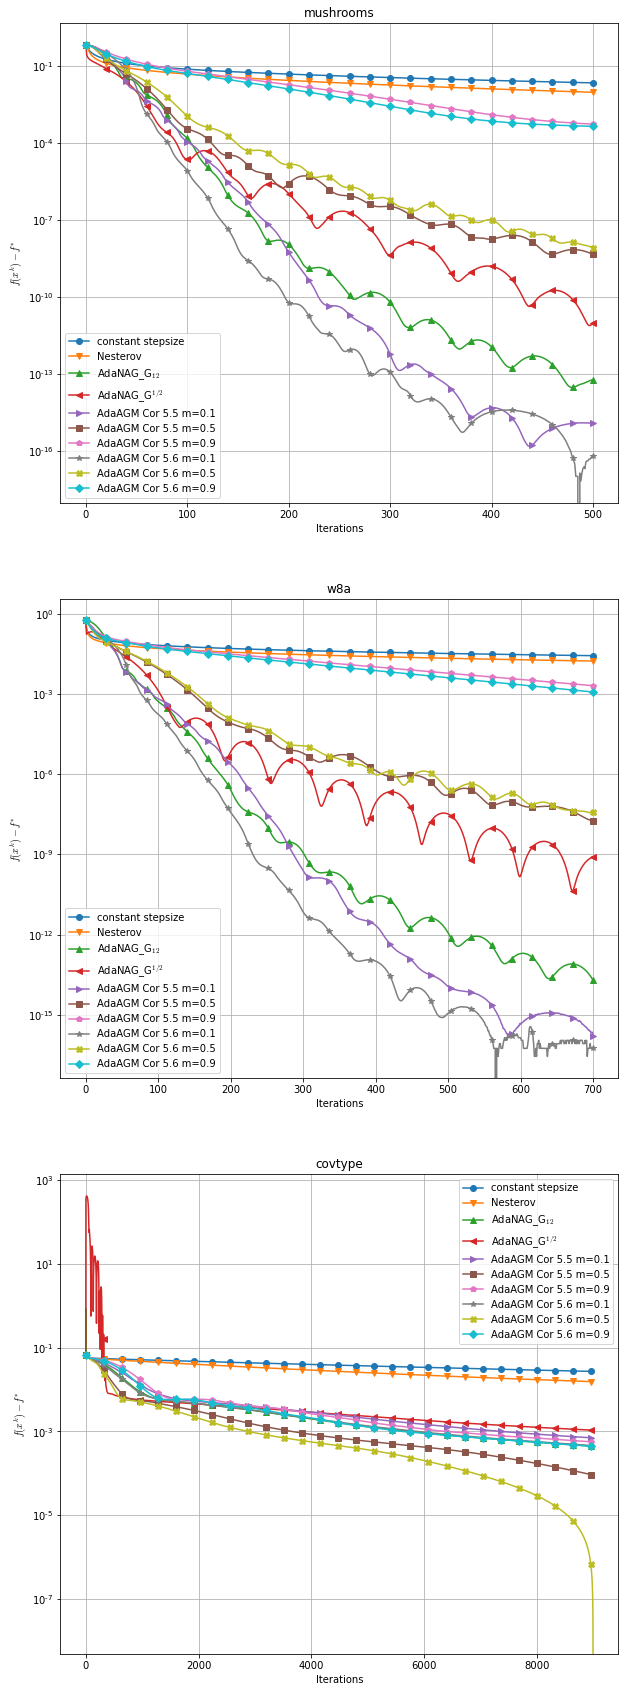

In [15]:
plt.rcParams["mathtext.fontset"] = "cm"
fig, ax = plt.subplots(3, figsize=(10,30))
labels = ['constant stepsize', 'Nesterov', 'AdaNAG_G$_{12}$', 'AdaNAG_G$^{1/2}$', 'AdaAGM Cor 5.5 m=0.1', 'AdaAGM Cor 5.5 m=0.5', 'AdaAGM Cor 5.5 m=0.9', 'AdaAGM Cor 5.6 m=0.1', 'AdaAGM Cor 5.6 m=0.5', 'AdaAGM Cor 5.6 m=0.9']
titles = ['mushrooms', 'w8a', 'covtype']
markers = ['o', 'v', '^', '<', '>', 's', 'p', '*', 'X', 'D'] 
mark_every = [20, 28, 320]
for k in range(3):
    for index, value_sequence in enumerate(function_values[k]):
        ax[k].plot(value_sequence - minimum[k], label=labels[index], marker=markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel('$f(x^{k}) - f^{*}$')
    ax[k].grid()

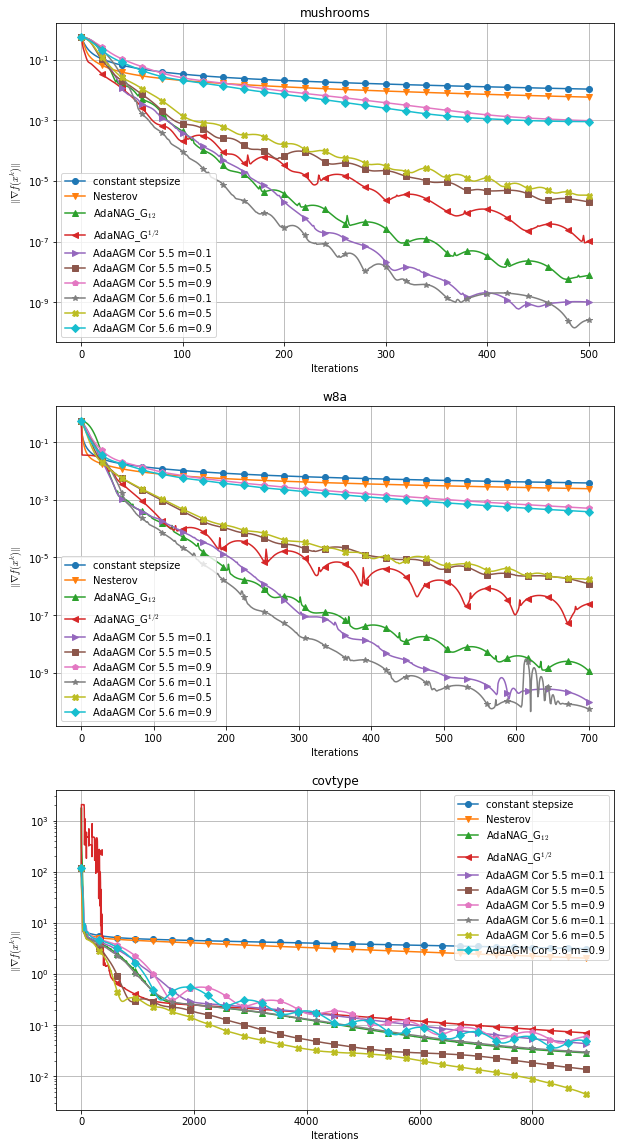

In [16]:
fig, ax = plt.subplots(3, figsize=(10,20))
for k in range(3):
    for index, gradient_sequence in enumerate(gradient_norms[k]):
        ax[k].plot(gradient_sequence, label=labels[index], marker = markers[index], markevery=mark_every[k])
    ax[k].set_yscale('log')
    ax[k].legend()
    ax[k].set_title(titles[k])
    ax[k].set_xlabel('Iterations')
    ax[k].set_ylabel(r'$\Vert \nabla f(x^k) \Vert$')
    ax[k].grid()